In [1]:
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.optimizers import Adam
from keras.models import Sequential, Model
from keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape
from keras.layers import Conv2D, Conv2DTranspose, Flatten, Input, Dropout
import tensorflow as tf
import os



DCGAN for CIFAR-10 - Generating: dog



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== DISCRIMINATOR ARCHITECTURE ===


Model: "disc_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 3)      │         4,803 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,733,507 (10.43 MB)

 Trainable params: 2,700,355 (10.30 MB)

 Non-trainable params: 33,152 (129.50 KB)


Generator params: 2,733,507
Discriminator params: 217,985

=== STARTING TRAINING ===
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

=== DATASET INFO ===
Training on class: dog
Number of images: 5000
Image shape: (32, 32, 3)
Epoch   25 | D loss: 1.2272 | G loss: 0.9904 | D_real_acc: 0.75 | D_fake_acc: 0.88
Epoch   50 | D loss: 1.2694 | G loss: 0.9454 | D_real_acc: 0.25 | D_fake_acc: 0.88
Epoch   75 | D loss: 1.2601 | G loss: 0.9758 | D_real_acc: 0.38 | D_fake_acc: 0.88
Epoch  100 | D loss: 1.2970 | G loss: 0.9245 | D_real_acc: 0.00 | D_fake_acc: 0.88


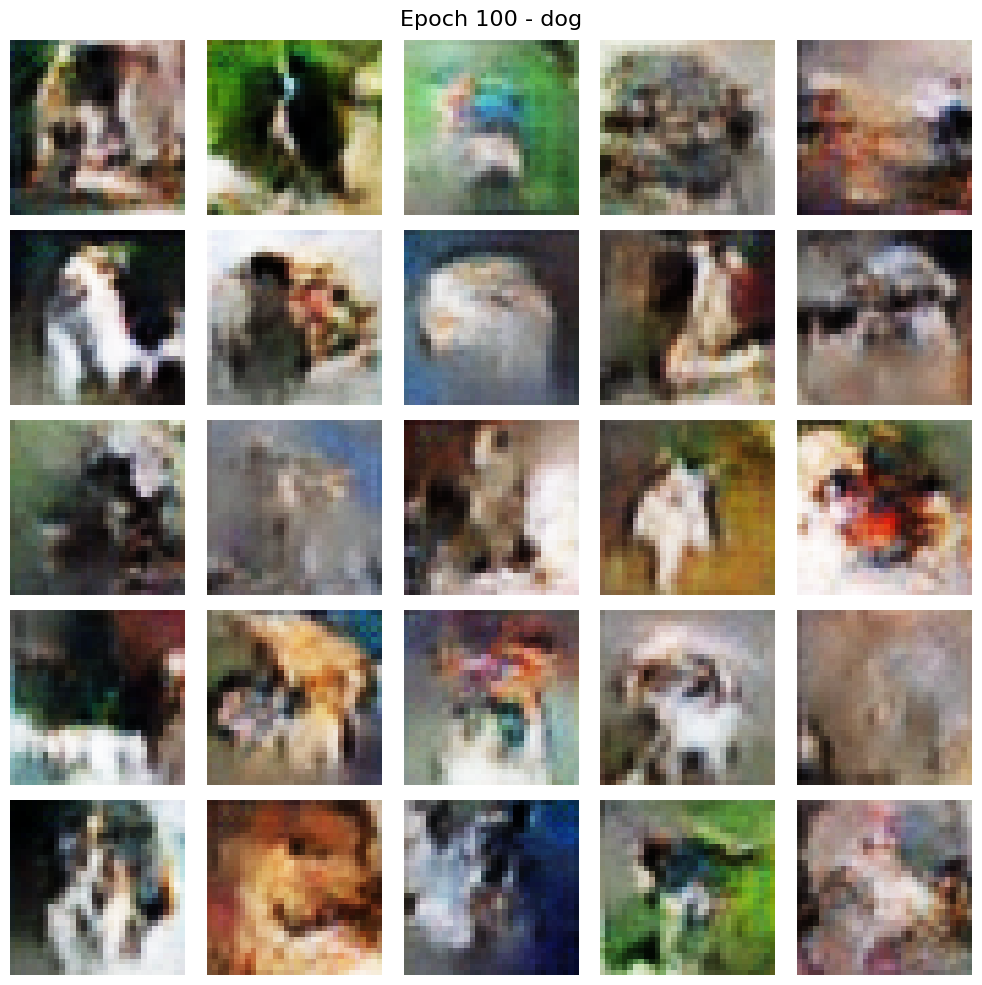

Epoch  125 | D loss: 1.3219 | G loss: 0.8920 | D_real_acc: 0.50 | D_fake_acc: 0.88
Epoch  150 | D loss: 1.3378 | G loss: 0.8691 | D_real_acc: 0.38 | D_fake_acc: 0.88
Epoch  175 | D loss: 1.3307 | G loss: 0.8677 | D_real_acc: 0.50 | D_fake_acc: 1.00
Epoch  200 | D loss: 1.3331 | G loss: 0.8655 | D_real_acc: 0.25 | D_fake_acc: 0.75


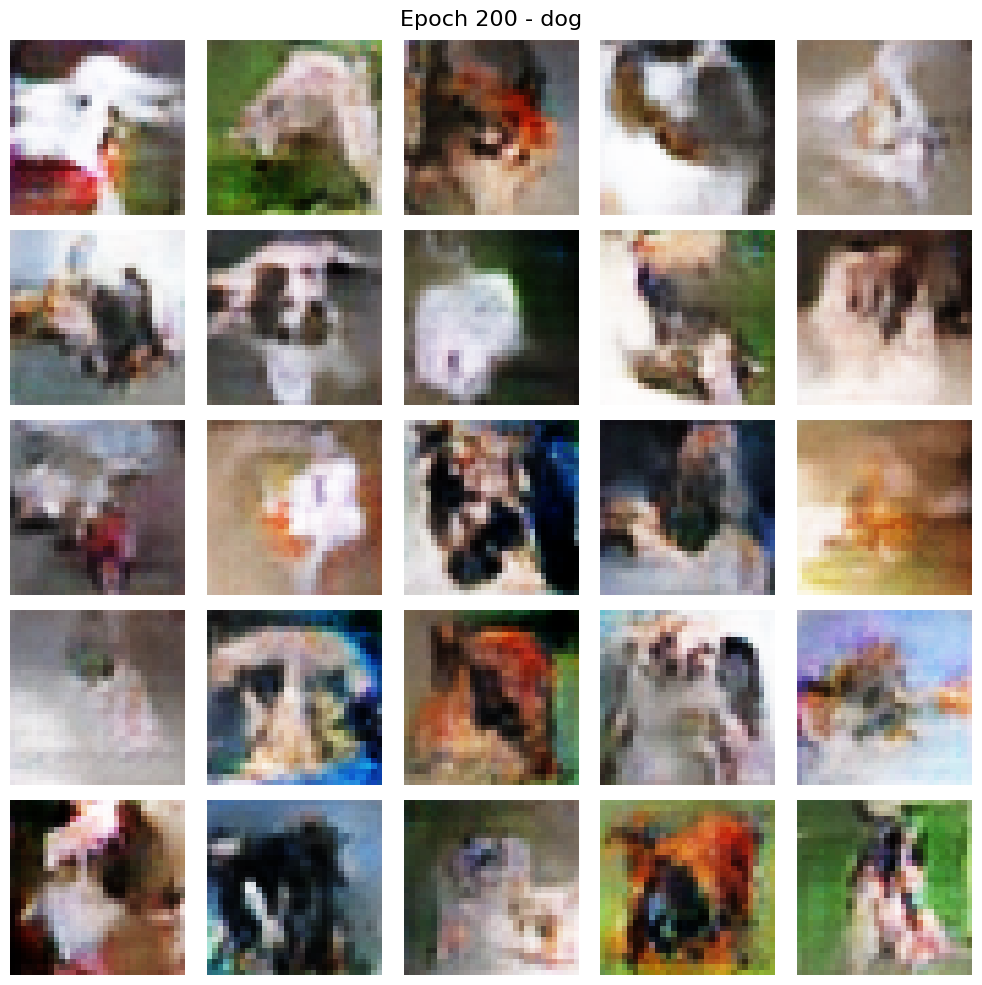

Epoch  225 | D loss: 1.3380 | G loss: 0.8585 | D_real_acc: 0.50 | D_fake_acc: 0.62
Epoch  250 | D loss: 1.3319 | G loss: 0.8589 | D_real_acc: 0.62 | D_fake_acc: 0.62
Epoch  275 | D loss: 1.3410 | G loss: 0.8543 | D_real_acc: 0.12 | D_fake_acc: 0.75
Epoch  300 | D loss: 1.3421 | G loss: 0.8582 | D_real_acc: 0.38 | D_fake_acc: 0.88


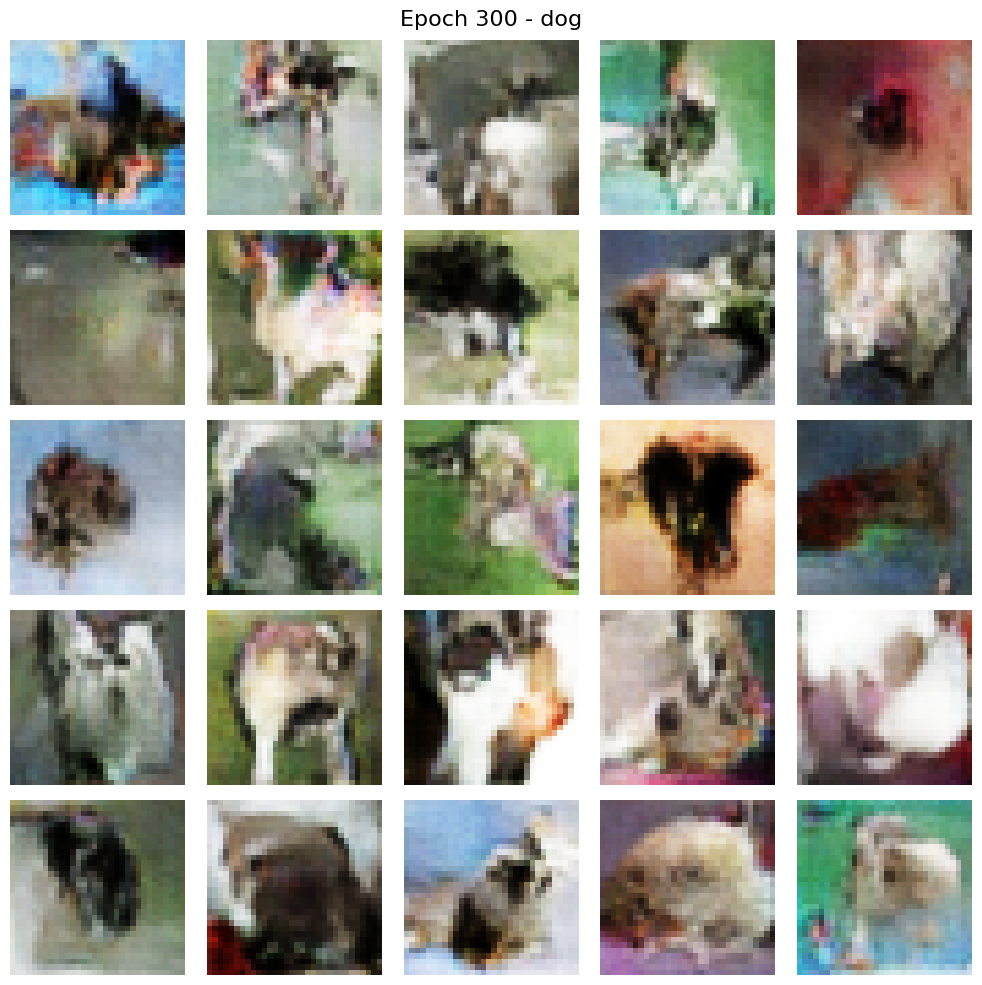

Epoch  325 | D loss: 1.3531 | G loss: 0.8455 | D_real_acc: 0.25 | D_fake_acc: 0.88
Epoch  350 | D loss: 1.3460 | G loss: 0.8482 | D_real_acc: 0.00 | D_fake_acc: 0.88
Epoch  375 | D loss: 1.3477 | G loss: 0.8530 | D_real_acc: 0.25 | D_fake_acc: 1.00
Epoch  400 | D loss: 1.3439 | G loss: 0.8515 | D_real_acc: 0.12 | D_fake_acc: 1.00


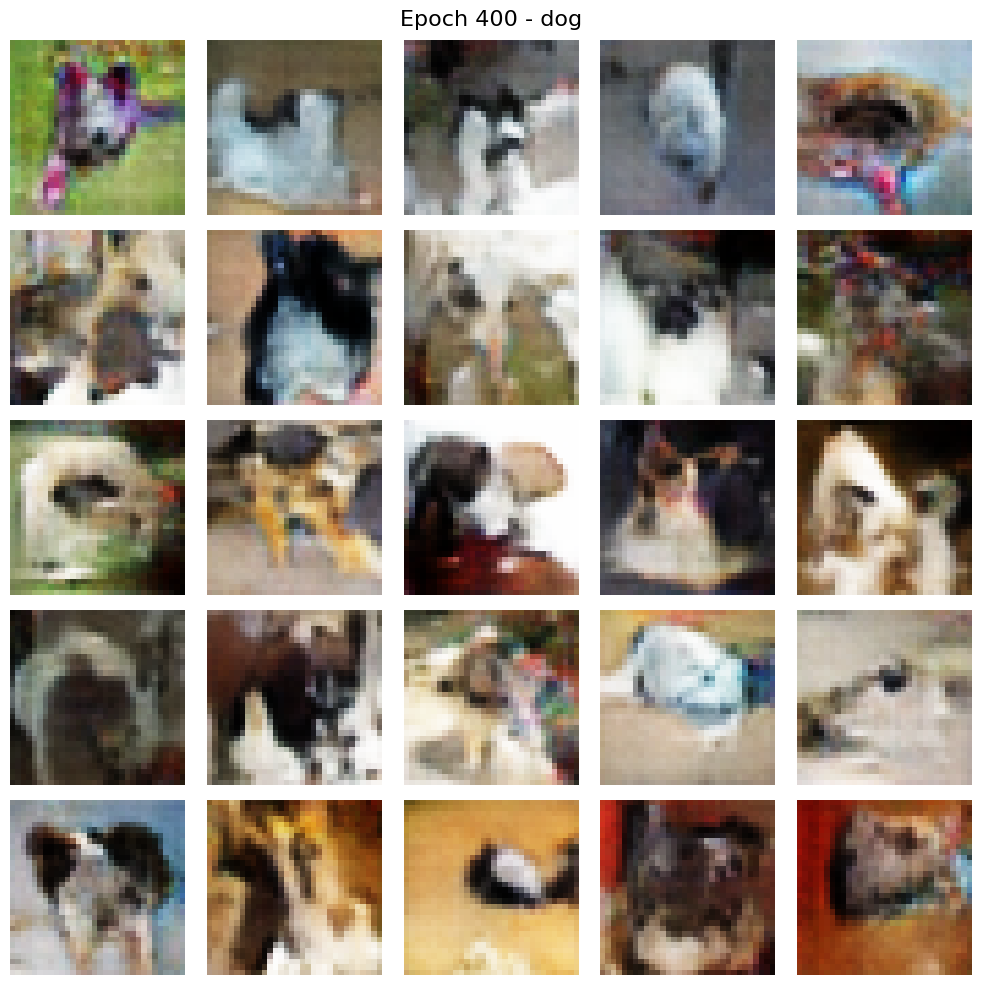

Epoch  425 | D loss: 1.3354 | G loss: 0.8648 | D_real_acc: 0.75 | D_fake_acc: 0.88
Epoch  450 | D loss: 1.3422 | G loss: 0.8537 | D_real_acc: 0.25 | D_fake_acc: 0.62
Epoch  475 | D loss: 1.3371 | G loss: 0.8584 | D_real_acc: 0.62 | D_fake_acc: 0.62
Epoch  500 | D loss: 1.3359 | G loss: 0.8633 | D_real_acc: 0.62 | D_fake_acc: 0.88


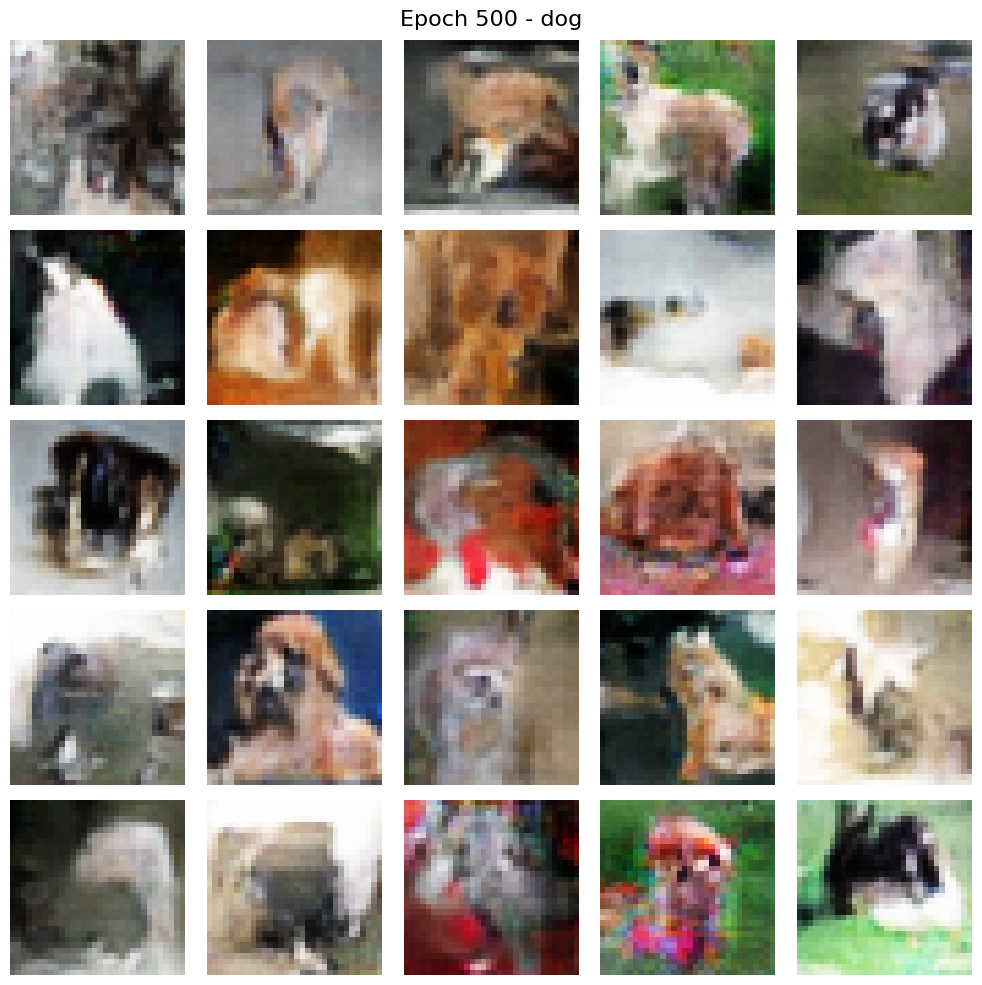

Epoch  525 | D loss: 1.3408 | G loss: 0.8587 | D_real_acc: 0.00 | D_fake_acc: 0.75
Epoch  550 | D loss: 1.3335 | G loss: 0.8669 | D_real_acc: 0.75 | D_fake_acc: 0.62
Epoch  575 | D loss: 1.3292 | G loss: 0.8666 | D_real_acc: 0.38 | D_fake_acc: 0.88
Epoch  600 | D loss: 1.3274 | G loss: 0.8750 | D_real_acc: 0.62 | D_fake_acc: 0.75


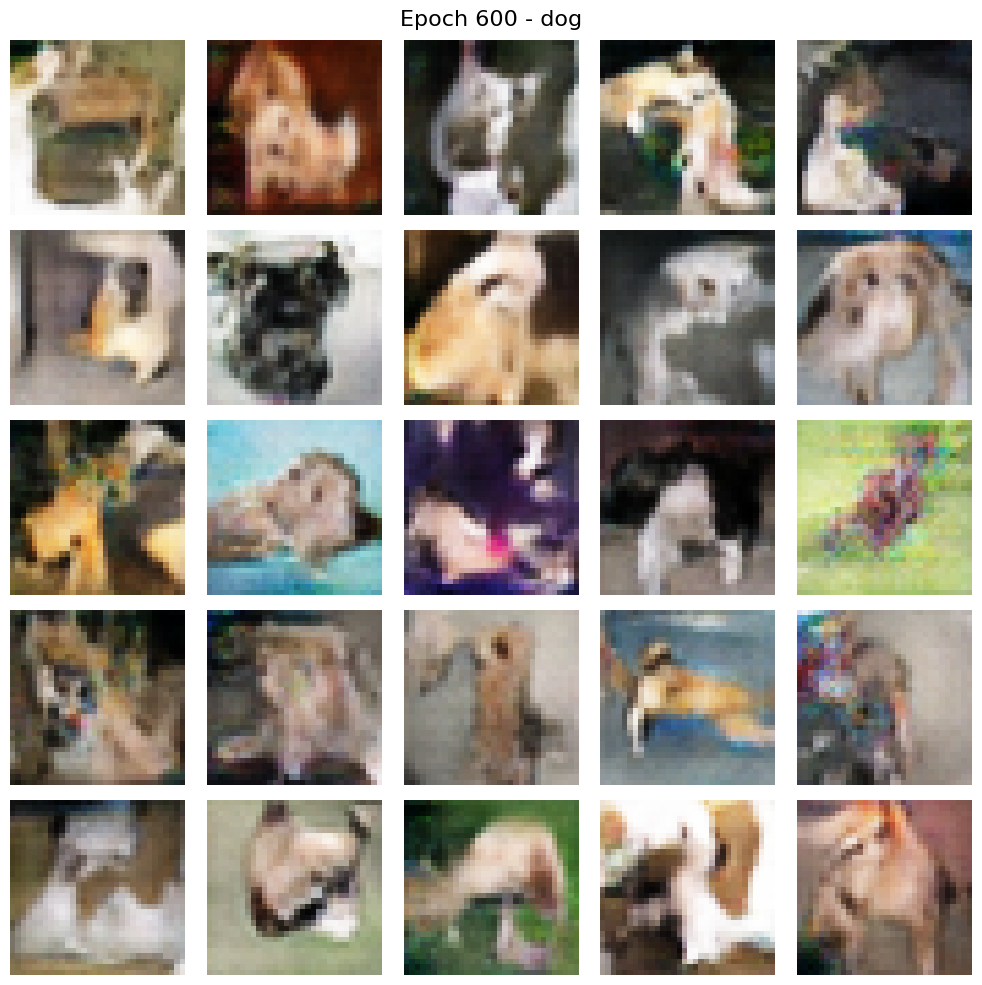

Epoch  625 | D loss: 1.3338 | G loss: 0.8719 | D_real_acc: 0.12 | D_fake_acc: 0.50
Epoch  650 | D loss: 1.3361 | G loss: 0.8737 | D_real_acc: 0.50 | D_fake_acc: 0.75
Epoch  675 | D loss: 1.3251 | G loss: 0.8763 | D_real_acc: 0.50 | D_fake_acc: 1.00
Epoch  700 | D loss: 1.3220 | G loss: 0.8869 | D_real_acc: 0.12 | D_fake_acc: 0.75


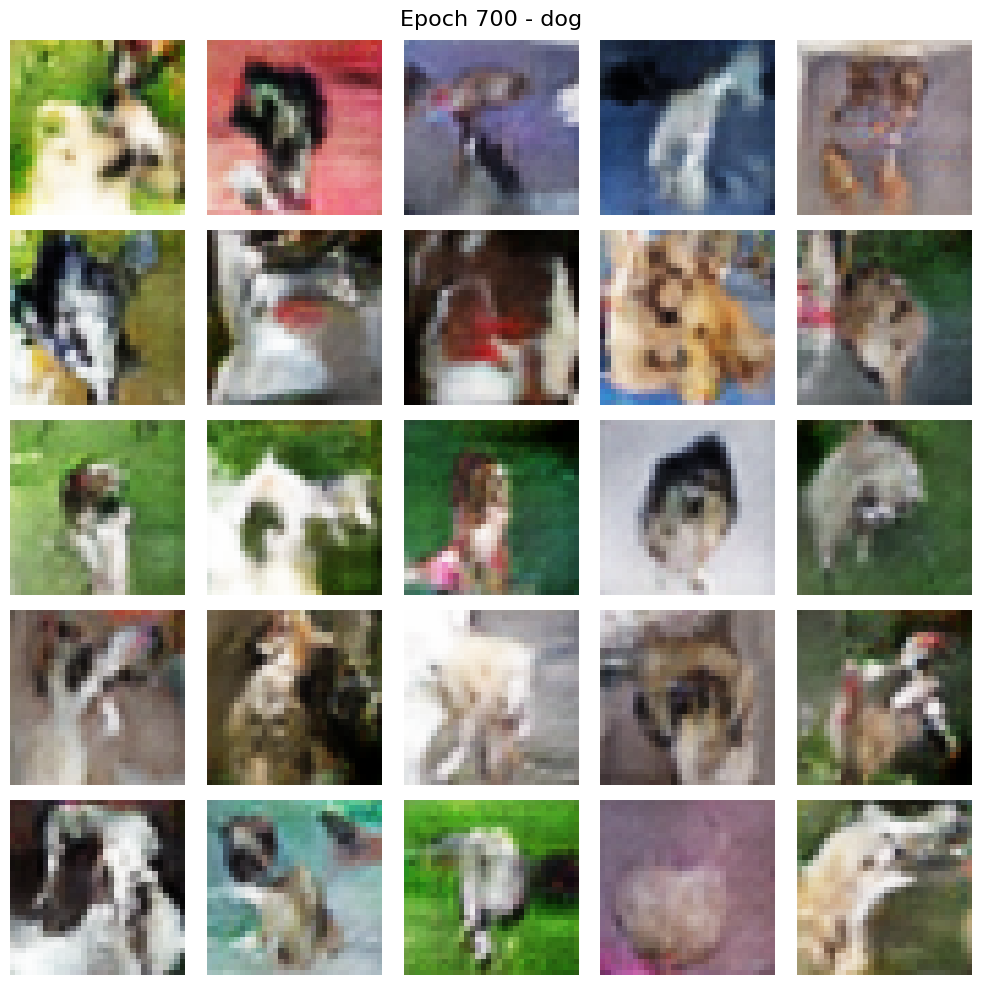

Epoch  725 | D loss: 1.3363 | G loss: 0.8730 | D_real_acc: 0.50 | D_fake_acc: 0.75
Epoch  750 | D loss: 1.3172 | G loss: 0.8870 | D_real_acc: 0.62 | D_fake_acc: 0.88
Epoch  775 | D loss: 1.3237 | G loss: 0.8871 | D_real_acc: 0.62 | D_fake_acc: 0.75
Epoch  800 | D loss: 1.3256 | G loss: 0.8809 | D_real_acc: 0.38 | D_fake_acc: 0.75


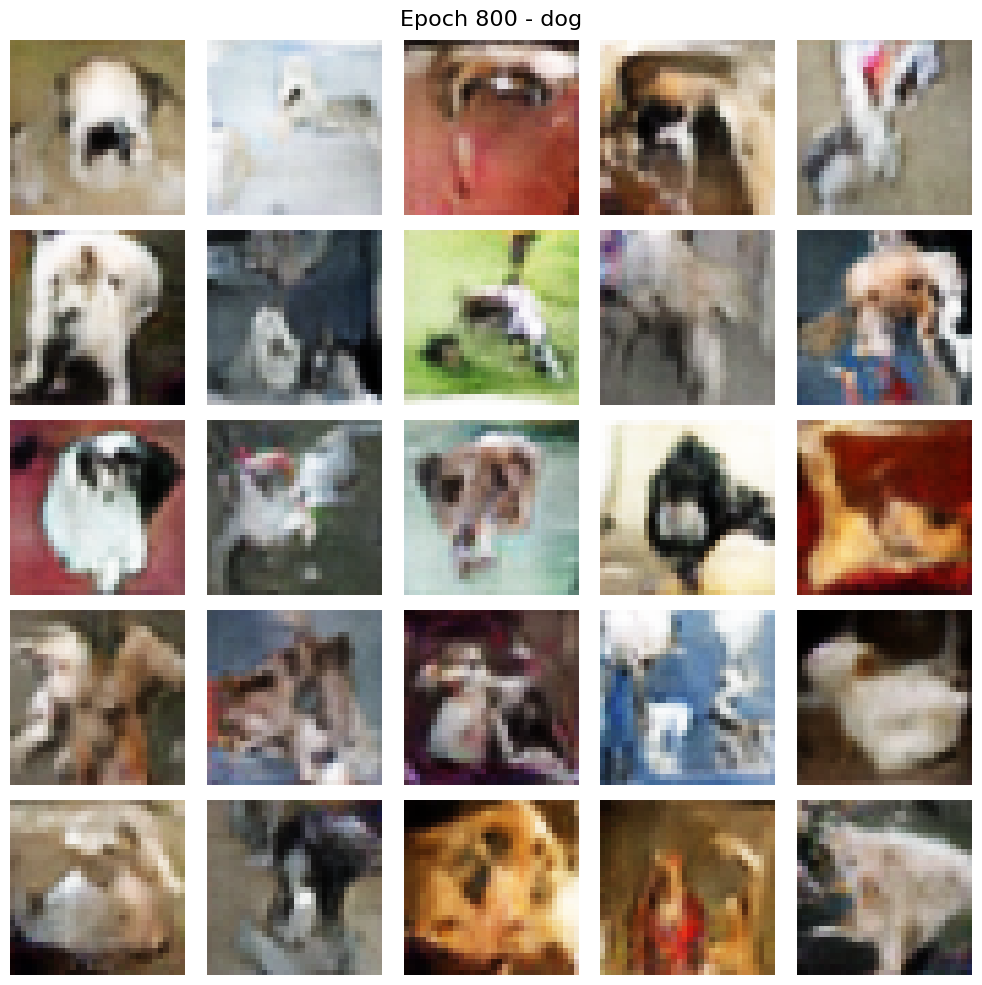

Epoch  825 | D loss: 1.3201 | G loss: 0.8924 | D_real_acc: 0.38 | D_fake_acc: 0.88
Epoch  850 | D loss: 1.3204 | G loss: 0.8938 | D_real_acc: 0.62 | D_fake_acc: 0.62
Epoch  875 | D loss: 1.3162 | G loss: 0.9002 | D_real_acc: 0.38 | D_fake_acc: 1.00
Epoch  900 | D loss: 1.3180 | G loss: 0.8964 | D_real_acc: 0.50 | D_fake_acc: 0.50


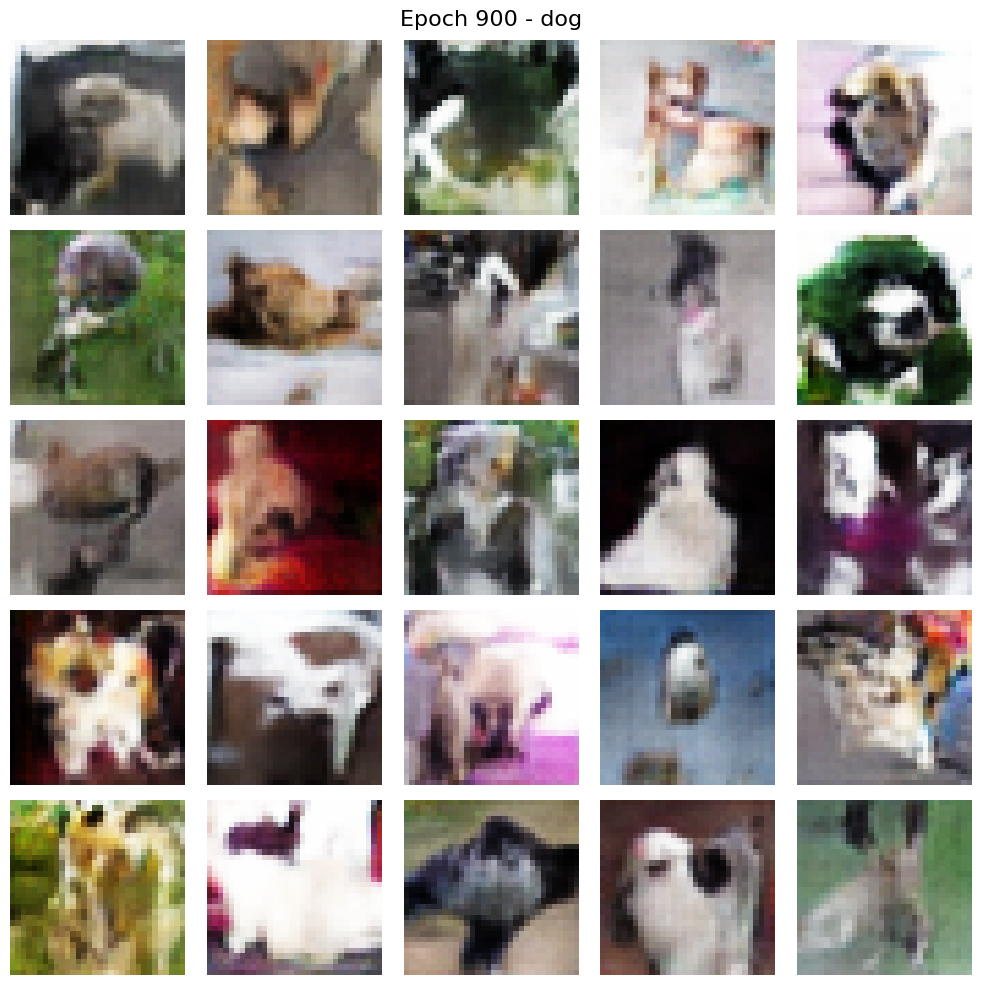

Epoch  925 | D loss: 1.3085 | G loss: 0.9032 | D_real_acc: 0.75 | D_fake_acc: 0.88
Epoch  950 | D loss: 1.3086 | G loss: 0.9077 | D_real_acc: 0.38 | D_fake_acc: 0.88
Epoch  975 | D loss: 1.3125 | G loss: 0.9058 | D_real_acc: 0.12 | D_fake_acc: 0.75
Epoch 1000 | D loss: 1.3093 | G loss: 0.9075 | D_real_acc: 0.25 | D_fake_acc: 1.00


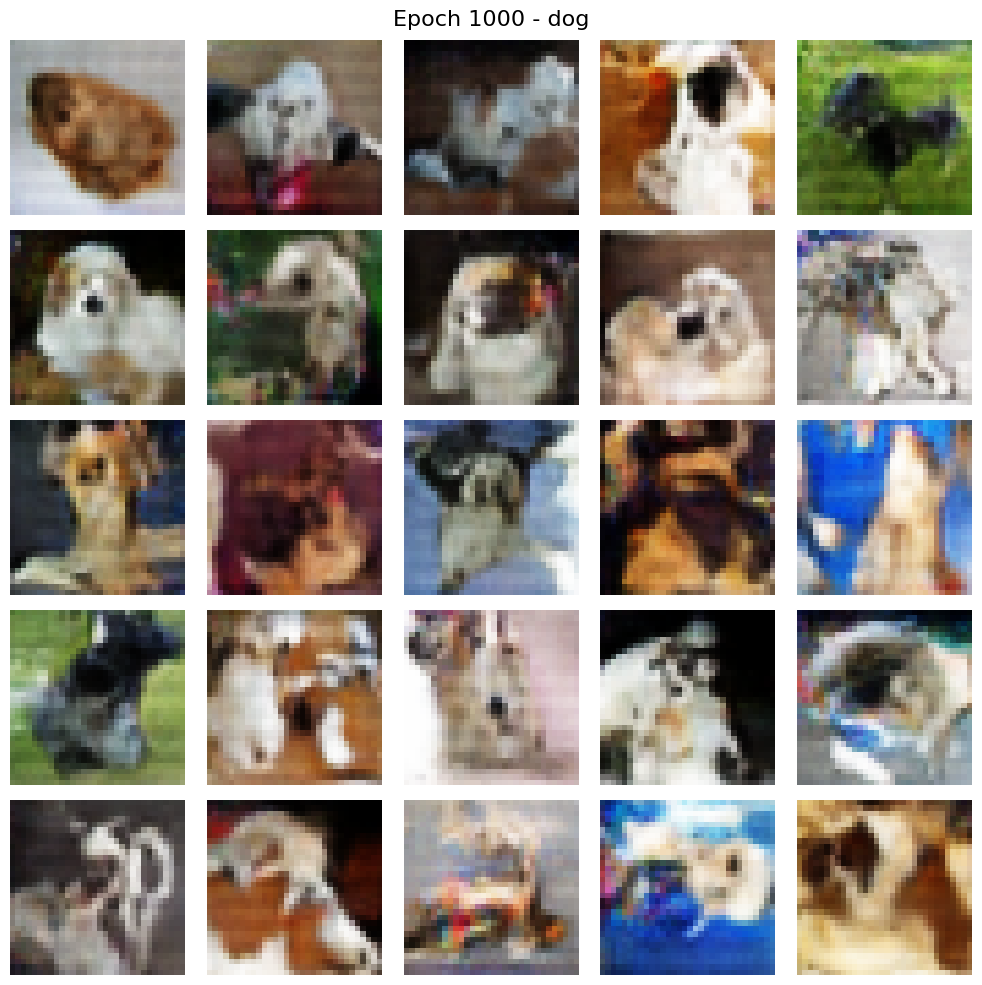

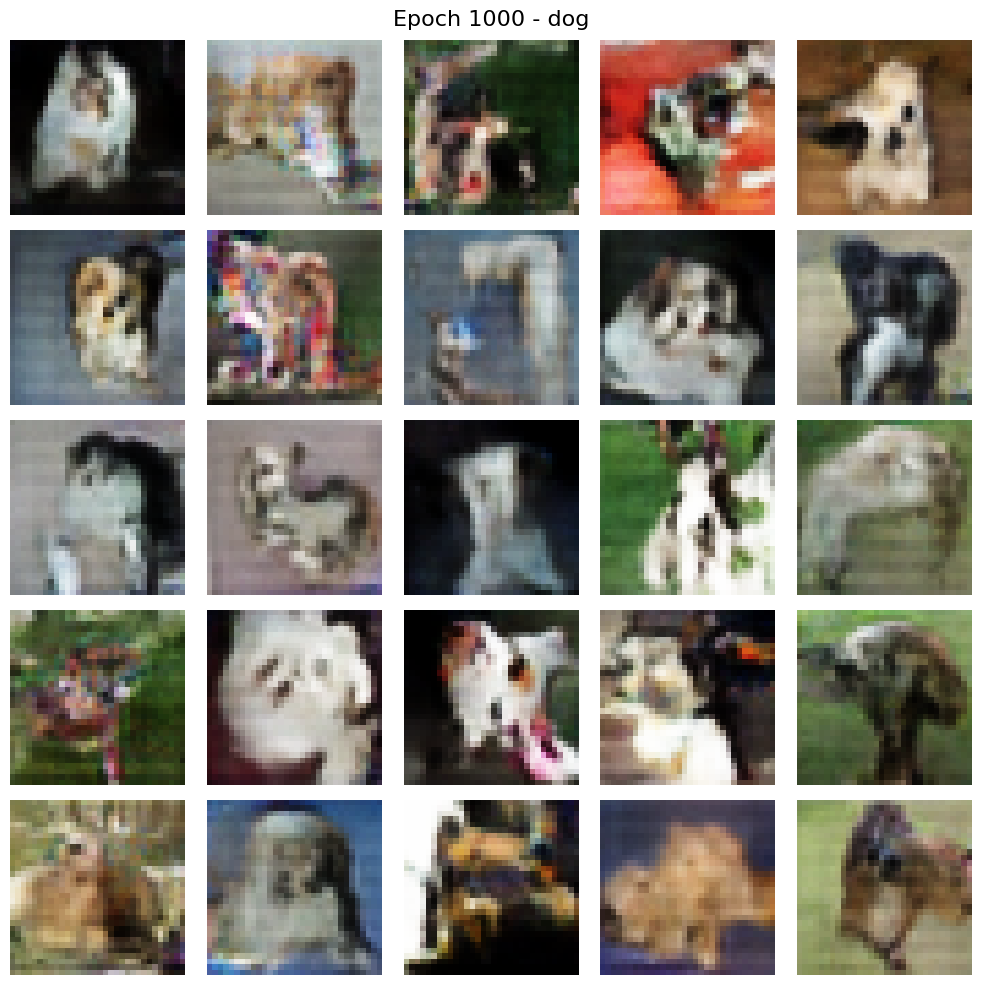

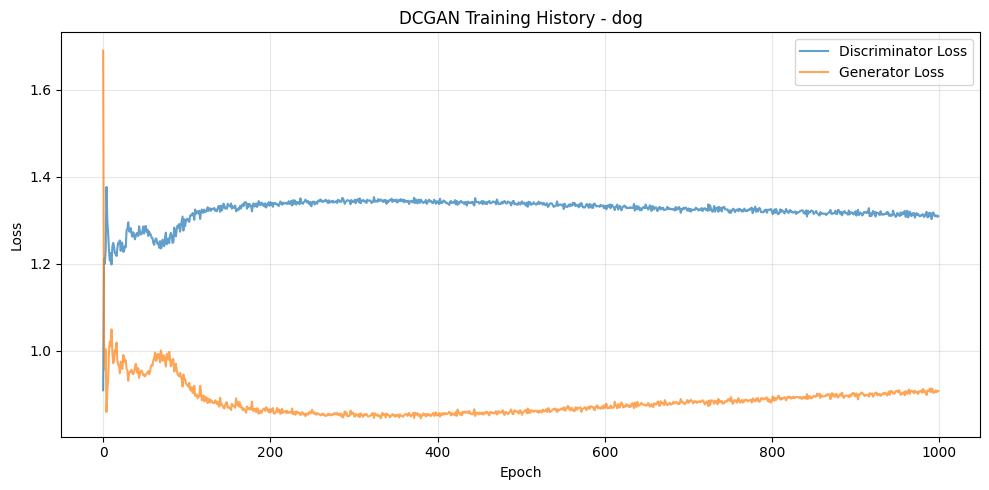


=== DEMONSTRATING NOISE VECTOR CONTROL ===
1. Random noise samples...


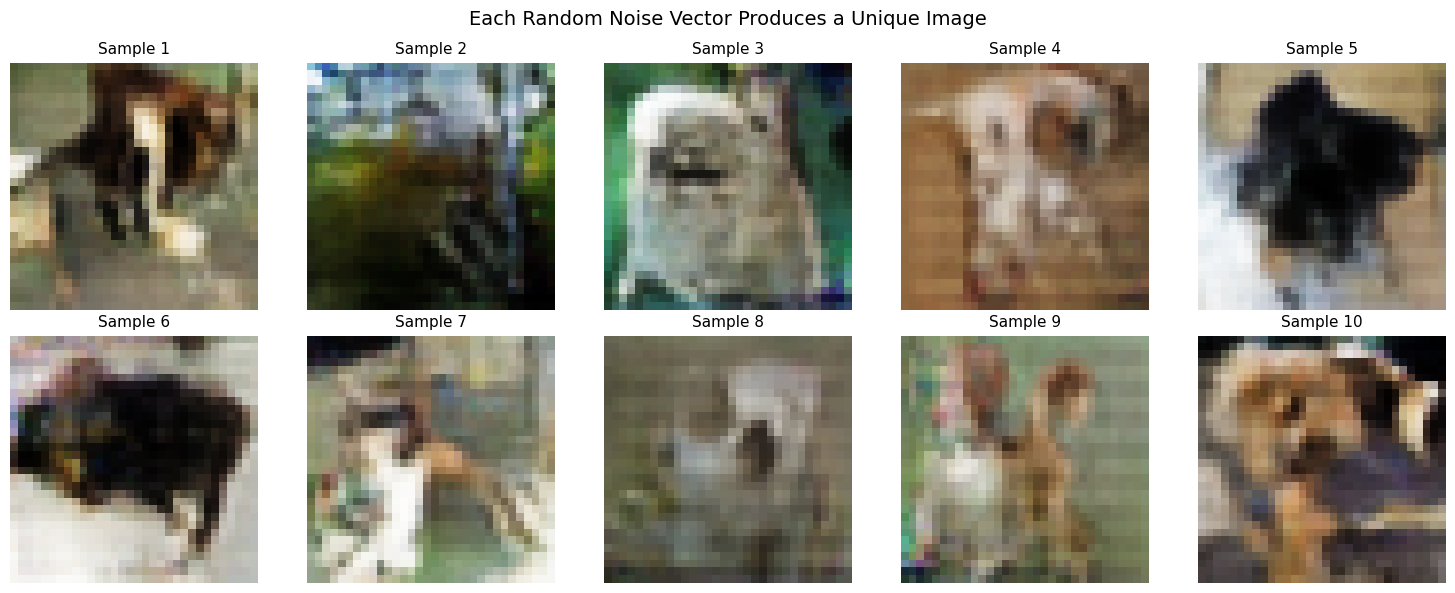

2. Latent space interpolation...


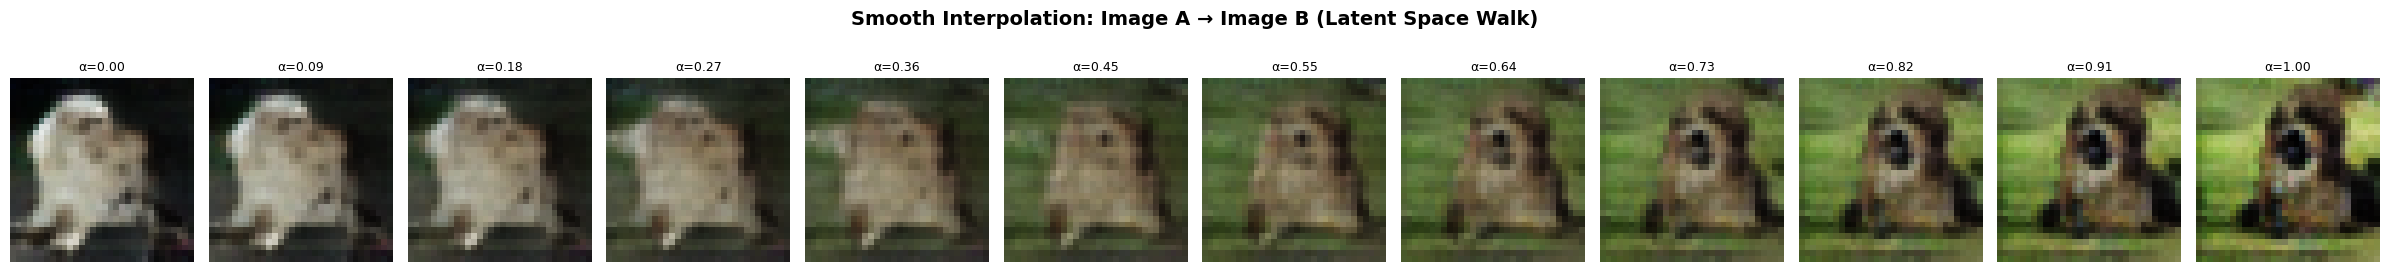

3. Multi-path interpolation from one seed...


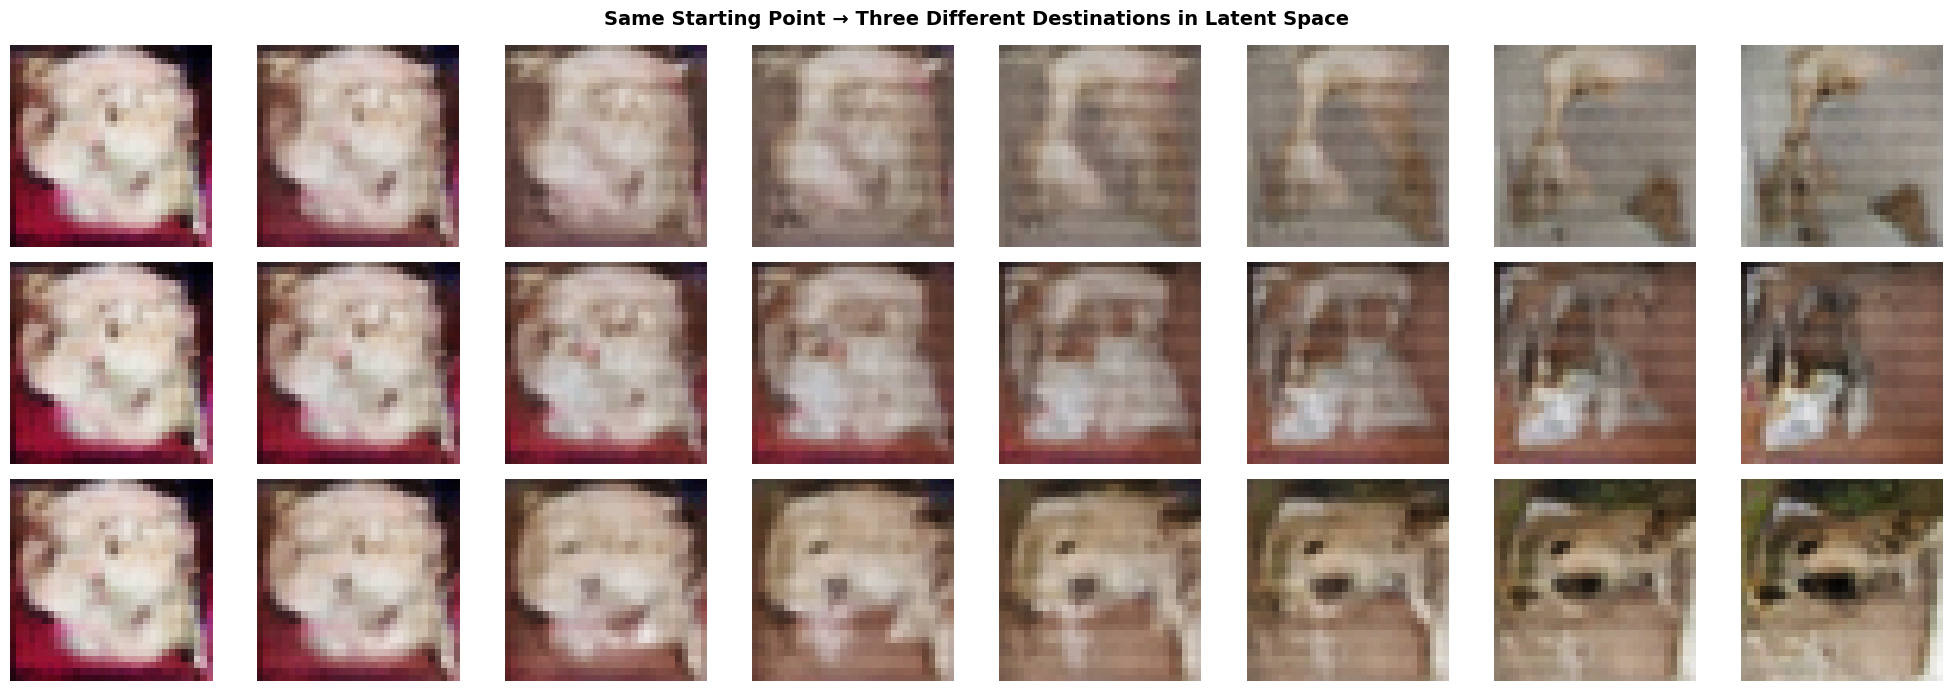

4. Dimension sweeps...


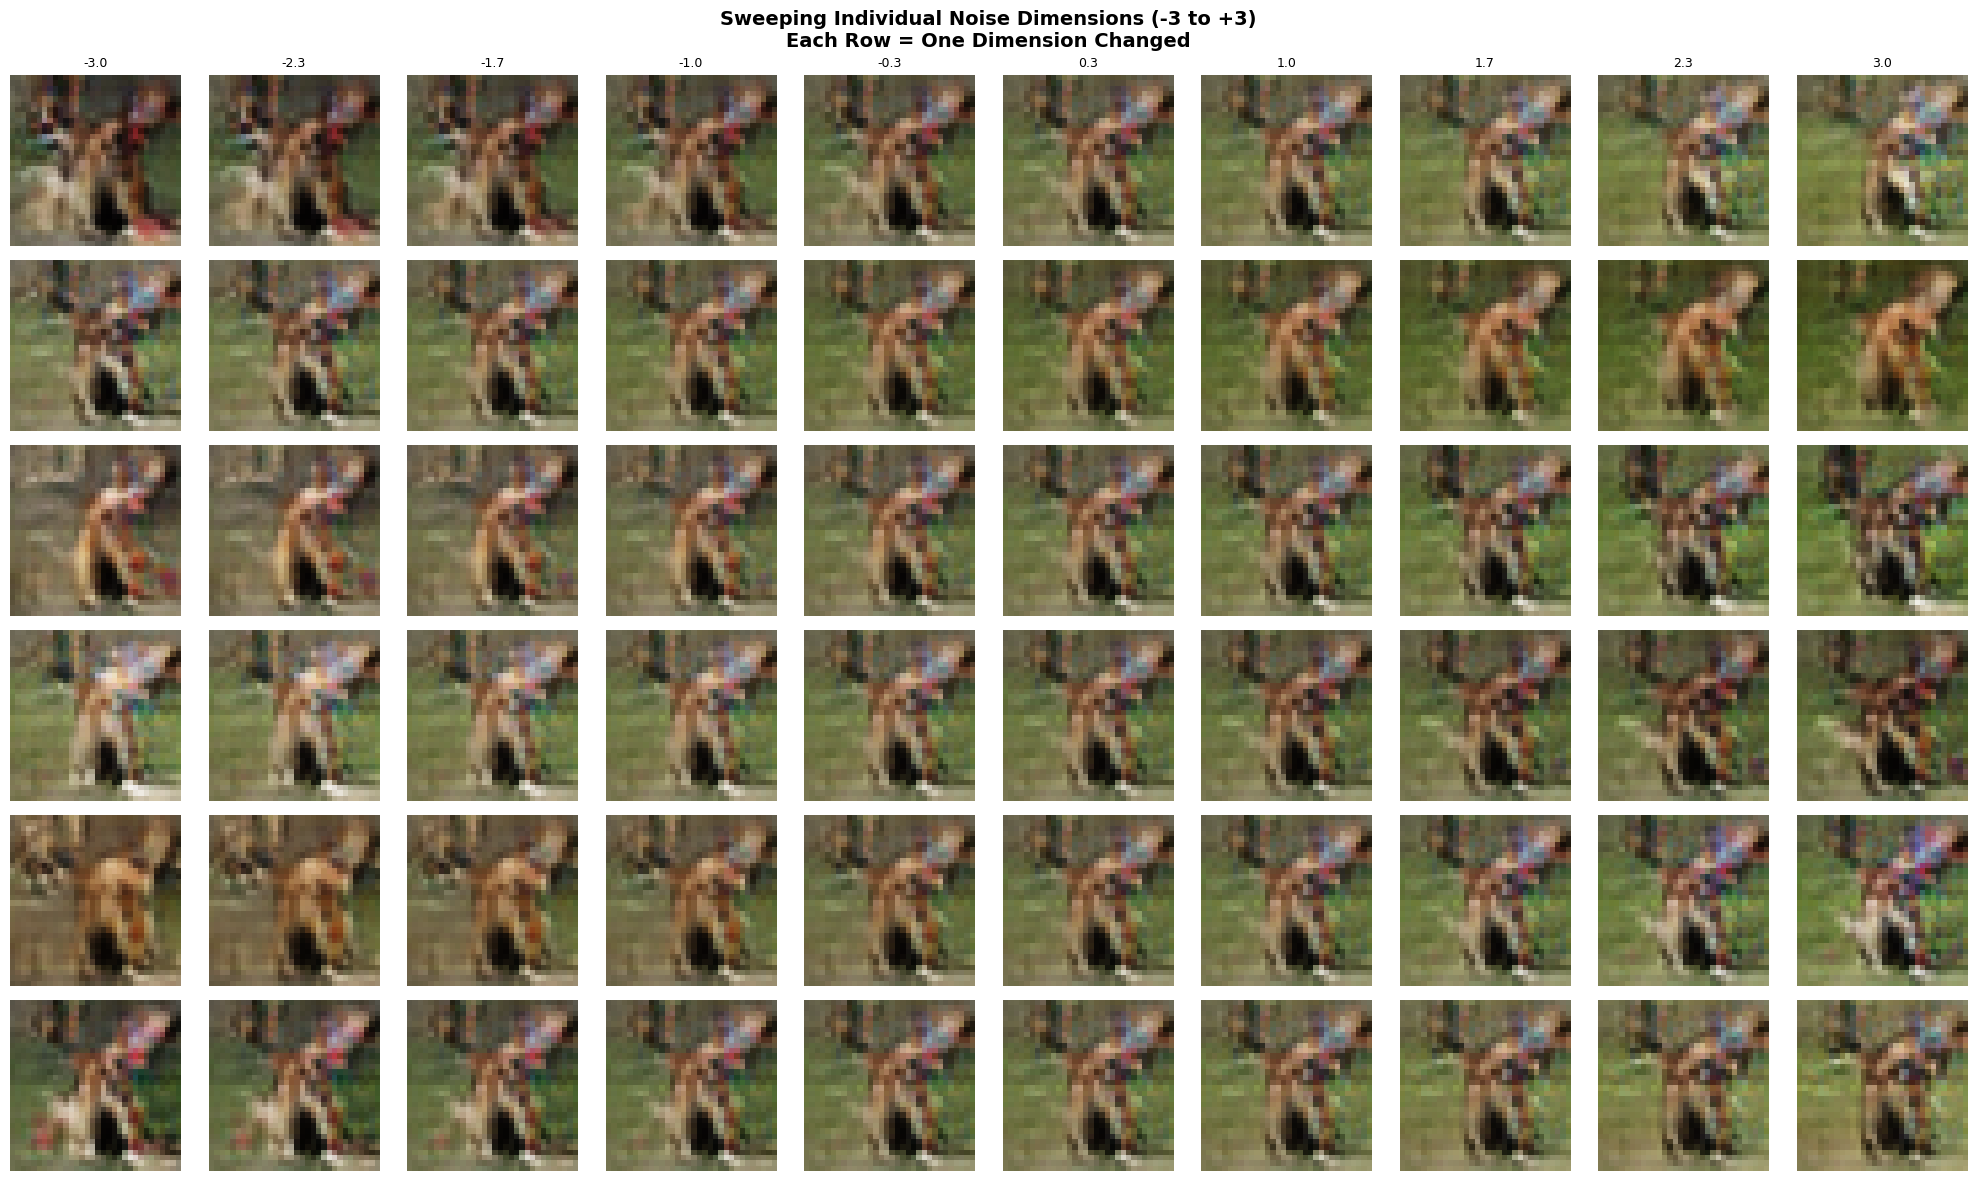

5. Noise magnitude scaling...


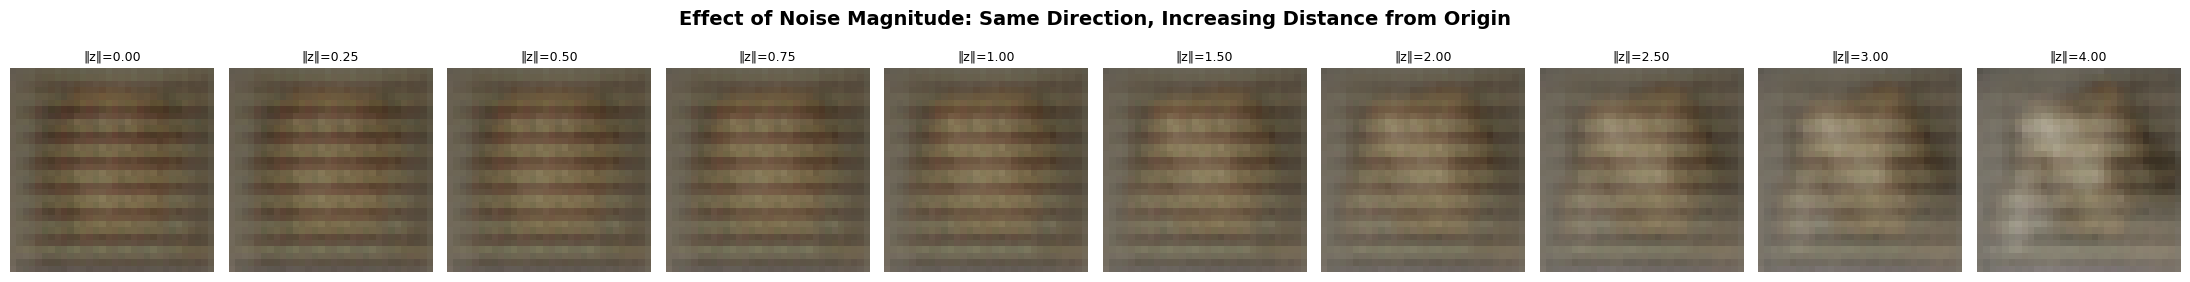

6. Sensitivity to small perturbations...


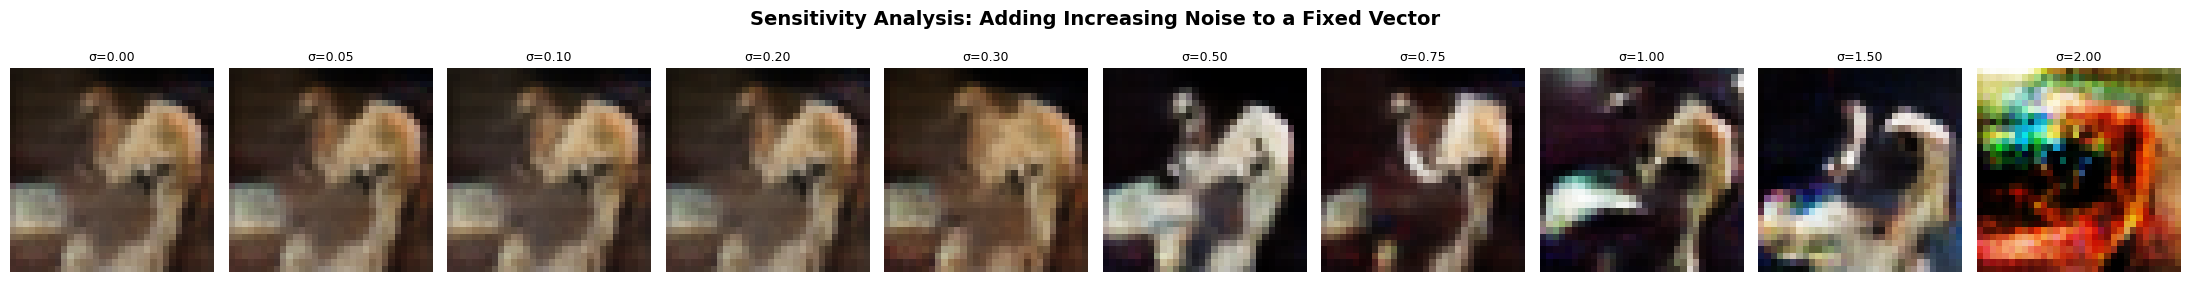


=== ALL NOISE CONTROL DEMOS SAVED ===
Files saved:
  demo1_random_samples.png          - Unique images from random noise
  demo2_interpolation.png            - Smooth A→B transition
  demo3_multipath_interpolation.png  - Same seed, 3 different destinations
  demo4_dimension_sweeps.png         - Individual dimension effects
  demo5_magnitude_scaling.png        - Distance from origin effects
  demo6_perturbation_sensitivity.png - Sensitivity to small changes

=== ALL DONE ===


In [2]:


class DCGAN():
    def __init__(self, class_id=6):
        """
        Initialize DCGAN for CIFAR-10
        class_id: Which CIFAR-10 class to generate (0-9)
        """
        self.img_rows = 32
        self.img_cols = 32
        self.channels = 3
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        self.latent_dim = 100
        self.class_id = class_id

        self.class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                            'dog', 'frog', 'horse', 'ship', 'truck']

        # FIX 1: Lower learning rate for stability
        self.d_optimizer = Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.999)
        self.g_optimizer = Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.999)

        # FIX 2: Use GradientTape approach (no combined model needed)
        self.discriminator = self.build_discriminator()
        self.generator = self.build_generator()

        self.cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

        print(f"\nGenerator params: {self.generator.count_params():,}")
        print(f"Discriminator params: {self.discriminator.count_params():,}")

    def build_generator(self):
        """
        Generator: Noise (100,) -> 8x8x256 -> 16x16x128 -> 32x32x3
        """
        model = Sequential(name="gen_net")

        # Foundation: 8x8x256
        model.add(Dense(8 * 8 * 256, use_bias=False, input_dim=self.latent_dim))
        model.add(LeakyReLU(negative_slope=0.2))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Reshape((8, 8, 256)))

        # Upsample to 16x16
        model.add(Conv2DTranspose(128, kernel_size=5, strides=2, padding='same', use_bias=False))
        model.add(LeakyReLU(negative_slope=0.2))
        model.add(BatchNormalization(momentum=0.8))

        # Upsample to 32x32
        model.add(Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False))
        model.add(LeakyReLU(negative_slope=0.2))
        model.add(BatchNormalization(momentum=0.8))

        # Output: 32x32x3
        model.add(Conv2D(self.channels, kernel_size=5, padding='same', activation='tanh'))

        print("\n=== GENERATOR ARCHITECTURE ===")
        model.summary()

        noise = Input(shape=(self.latent_dim,))
        img = model(noise)
        return Model(noise, img, name="generator")

    def build_discriminator(self):
        """
        Discriminator: 32x32x3 -> 16x16x64 -> 8x8x128 -> 1
        """
        model = Sequential(name="disc_net")

        # 32x32 -> 16x16
        model.add(Conv2D(64, kernel_size=5, strides=2, padding='same',
                         input_shape=self.img_shape))
        model.add(LeakyReLU(negative_slope=0.2))
        model.add(Dropout(0.3))

        # 16x16 -> 8x8
        model.add(Conv2D(128, kernel_size=5, strides=2, padding='same'))
        model.add(LeakyReLU(negative_slope=0.2))
        model.add(Dropout(0.3))

        model.add(Flatten())
        model.add(Dense(1, activation='sigmoid'))

        print("\n=== DISCRIMINATOR ARCHITECTURE ===")
        model.summary()

        img = Input(shape=self.img_shape)
        validity = model(img)
        return Model(img, validity, name="discriminator")

    def load_data(self):
        """Load CIFAR-10 and filter to specific class"""
        (X_train, y_train), (_, _) = cifar10.load_data()
        X_train = X_train[y_train.flatten() == self.class_id]
        X_train = (X_train.astype(np.float32) - 127.5) / 127.5

        print(f"\n=== DATASET INFO ===")
        print(f"Training on class: {self.class_names[self.class_id]}")
        print(f"Number of images: {X_train.shape[0]}")
        print(f"Image shape: {X_train.shape[1:]}")
        return X_train

    def discriminator_loss(self, real_output, fake_output):
        real_loss = self.cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
        fake_loss = self.cross_entropy(tf.zeros_like(fake_output), fake_output)
        return real_loss + fake_loss

    def generator_loss(self, fake_output):
        return self.cross_entropy(tf.ones_like(fake_output), fake_output)

    @tf.function
    def train_step(self, images):
        batch_size = tf.shape(images)[0]
        noise = tf.random.normal([batch_size, self.latent_dim])

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(noise, training=True)

            real_output = self.discriminator(images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.generator_loss(fake_output)
            disc_loss = self.discriminator_loss(real_output, fake_output)

        grad_gen = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        grad_disc = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.g_optimizer.apply_gradients(zip(grad_gen, self.generator.trainable_variables))
        self.d_optimizer.apply_gradients(zip(grad_disc, self.discriminator.trainable_variables))

        real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))
        fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))

        return gen_loss, disc_loss, real_acc, fake_acc

    def train(self, epochs=1000, batch_size=32, save_interval=100):
        """
        True epoch-based training (full passes over the dataset)
        instead of step-based training. Also smaller batch_size=32.
        """
        X_train = self.load_data()

        # Create tf.data pipeline
        train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
        train_dataset = train_dataset.shuffle(len(X_train)).batch(batch_size)

        d_losses = []
        g_losses = []

        for epoch in range(1, epochs + 1):
            epoch_g_loss = []
            epoch_d_loss = []

            # Train on ALL batches (true epoch)
            for batch in train_dataset:
                gen_loss, disc_loss, real_acc, fake_acc = self.train_step(batch)
                epoch_g_loss.append(gen_loss.numpy())
                epoch_d_loss.append(disc_loss.numpy())

            avg_g = np.mean(epoch_g_loss)
            avg_d = np.mean(epoch_d_loss)
            d_losses.append(avg_d)
            g_losses.append(avg_g)

            if epoch % 25 == 0:
                print(f"Epoch {epoch:4d} | D loss: {avg_d:.4f} | G loss: {avg_g:.4f} | "
                      f"D_real_acc: {real_acc:.2f} | D_fake_acc: {fake_acc:.2f}")

            if epoch % save_interval == 0:
                self.save_imgs(epoch)

        self.save_imgs(epochs)
        self.plot_training_history(d_losses, g_losses)

    def save_imgs(self, epoch):
        """Generate and save a 5x5 grid"""
        r, c = 5, 5
        noise = tf.random.normal([r * c, self.latent_dim])
        gen_imgs = self.generator(noise, training=False)
        gen_imgs = np.clip((gen_imgs.numpy() + 1.0) / 2.0, 0, 1)

        fig, axs = plt.subplots(r, c, figsize=(10, 10))
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt])
                axs[i, j].axis('off')
                cnt += 1
        fig.suptitle(f'Epoch {epoch} - {self.class_names[self.class_id]}', fontsize=16)
        plt.tight_layout()
        fig.savefig(f"./images/cifar10_{self.class_names[self.class_id]}_{epoch}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

    def plot_training_history(self, d_losses, g_losses):
        """Plot training loss curves"""
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        ax.plot(d_losses, label='Discriminator Loss', alpha=0.7)
        ax.plot(g_losses, label='Generator Loss', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'DCGAN Training History - {self.class_names[self.class_id]}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'./images/training_history_{self.class_names[self.class_id]}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

    def demonstrate_noise_control(self):
        """
        Comprehensive noise vector control demonstrations.
        6 different visualizations.
        """
        print("\n=== DEMONSTRATING NOISE VECTOR CONTROL ===")

        # --------------------------------------------------------
        # 1. Random noise vectors -> diverse outputs
        # --------------------------------------------------------
        print("1. Random noise samples...")
        noise_samples = tf.random.normal([10, self.latent_dim])
        gen_imgs = self.generator(noise_samples, training=False)
        gen_imgs = np.clip((gen_imgs.numpy() + 1.0) / 2.0, 0, 1)

        fig, axs = plt.subplots(2, 5, figsize=(15, 6))
        for i in range(10):
            axs[i // 5, i % 5].imshow(gen_imgs[i])
            axs[i // 5, i % 5].set_title(f'Sample {i+1}', fontsize=11)
            axs[i // 5, i % 5].axis('off')
        plt.suptitle('Each Random Noise Vector Produces a Unique Image', fontsize=14)
        plt.tight_layout()
        plt.savefig('./images/demo1_random_samples.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        # --------------------------------------------------------
        # 2. Smooth interpolation between two noise vectors
        # --------------------------------------------------------
        print("2. Latent space interpolation...")
        noise_a = tf.random.normal([1, self.latent_dim])
        noise_b = tf.random.normal([1, self.latent_dim])

        steps = 12
        interp_imgs = []
        for alpha in np.linspace(0, 1, steps):
            interp = (1 - alpha) * noise_a + alpha * noise_b
            img = self.generator(interp, training=False)
            interp_imgs.append(img[0].numpy())

        interp_imgs = np.clip((np.array(interp_imgs) + 1.0) / 2.0, 0, 1)

        fig, axs = plt.subplots(1, steps, figsize=(24, 3))
        for i in range(steps):
            axs[i].imshow(interp_imgs[i])
            axs[i].set_title(f'α={i/(steps-1):.2f}', fontsize=9)
            axs[i].axis('off')
        plt.suptitle('Smooth Interpolation: Image A → Image B (Latent Space Walk)',
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./images/demo2_interpolation.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        # --------------------------------------------------------
        # 3. Multi-path interpolation (A->B, A->C, A->D)
        # --------------------------------------------------------
        print("3. Multi-path interpolation from one seed...")
        seed = tf.random.normal([1, self.latent_dim])
        targets = [tf.random.normal([1, self.latent_dim]) for _ in range(3)]
        n_steps = 8

        fig, axs = plt.subplots(3, n_steps, figsize=(20, 7))
        path_labels = ['Path A→B', 'Path A→C', 'Path A→D']

        for row, target in enumerate(targets):
            for col, alpha in enumerate(np.linspace(0, 1, n_steps)):
                interp = (1 - alpha) * seed + alpha * target
                img = self.generator(interp, training=False)
                img = np.clip((img[0].numpy() + 1.0) / 2.0, 0, 1)
                axs[row, col].imshow(img)
                axs[row, col].axis('off')
                if col == 0:
                    axs[row, col].set_ylabel(path_labels[row], fontsize=12, fontweight='bold')

        plt.suptitle('Same Starting Point → Three Different Destinations in Latent Space',
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./images/demo3_multipath_interpolation.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        # --------------------------------------------------------
        # 4. Single dimension sweeps across multiple dimensions
        # --------------------------------------------------------
        print("4. Dimension sweeps...")
        base_noise = np.random.normal(0, 1, (1, self.latent_dim))
        dims_to_explore = [0, 10, 25, 50, 75, 99]
        sweep_values = np.linspace(-3, 3, 10)

        fig, axs = plt.subplots(len(dims_to_explore), len(sweep_values),
                                figsize=(20, 12))

        for row, dim in enumerate(dims_to_explore):
            for col, val in enumerate(sweep_values):
                noise_var = base_noise.copy()
                noise_var[0, dim] = val
                img = self.generator(noise_var.astype(np.float32), training=False)
                img = np.clip((img[0].numpy() + 1.0) / 2.0, 0, 1)
                axs[row, col].imshow(img)
                axs[row, col].axis('off')
                if col == 0:
                    axs[row, col].set_ylabel(f'dim[{dim}]', fontsize=11, fontweight='bold')
                if row == 0:
                    axs[row, col].set_title(f'{val:.1f}', fontsize=9)

        plt.suptitle('Sweeping Individual Noise Dimensions (-3 to +3)\nEach Row = One Dimension Changed',
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./images/demo4_dimension_sweeps.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        # --------------------------------------------------------
        # 5. Noise magnitude scaling
        # --------------------------------------------------------
        print("5. Noise magnitude scaling...")
        direction = np.random.normal(0, 1, (1, self.latent_dim))
        direction = direction / np.linalg.norm(direction)

        scales = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
        fig, axs = plt.subplots(1, len(scales), figsize=(22, 3))

        for i, scale in enumerate(scales):
            noise = (direction * scale).astype(np.float32)
            img = self.generator(noise, training=False)
            img = np.clip((img[0].numpy() + 1.0) / 2.0, 0, 1)
            axs[i].imshow(img)
            axs[i].set_title(f'‖z‖={scale:.2f}', fontsize=9)
            axs[i].axis('off')

        plt.suptitle('Effect of Noise Magnitude: Same Direction, Increasing Distance from Origin',
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./images/demo5_magnitude_scaling.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        # --------------------------------------------------------
        # 6. Sensitivity to small perturbations
        # --------------------------------------------------------
        print("6. Sensitivity to small perturbations...")
        base = np.random.normal(0, 1, (1, self.latent_dim))
        perturbation_scales = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

        fig, axs = plt.subplots(1, len(perturbation_scales), figsize=(22, 3))

        for i, scale in enumerate(perturbation_scales):
            perturbed = base + scale * np.random.normal(0, 1, (1, self.latent_dim))
            img = self.generator(perturbed.astype(np.float32), training=False)
            img = np.clip((img[0].numpy() + 1.0) / 2.0, 0, 1)
            axs[i].imshow(img)
            axs[i].set_title(f'σ={scale:.2f}', fontsize=9)
            axs[i].axis('off')

        plt.suptitle('Sensitivity Analysis: Adding Increasing Noise to a Fixed Vector',
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('./images/demo6_perturbation_sensitivity.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        print("\n=== ALL NOISE CONTROL DEMOS SAVED ===")
        print("Files saved:")
        print("  demo1_random_samples.png          - Unique images from random noise")
        print("  demo2_interpolation.png            - Smooth A→B transition")
        print("  demo3_multipath_interpolation.png  - Same seed, 3 different destinations")
        print("  demo4_dimension_sweeps.png         - Individual dimension effects")
        print("  demo5_magnitude_scaling.png        - Distance from origin effects")
        print("  demo6_perturbation_sensitivity.png - Sensitivity to small changes")


# ========== MAIN EXECUTION ==========
if __name__ == '__main__':
    os.makedirs('./images', exist_ok=True)

    CLASS_ID = 5

    print(f"\n{'='*50}")
    print(f"DCGAN for CIFAR-10 - Generating: {['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'][CLASS_ID]}")
    print(f"{'='*50}\n")

    dcgan = DCGAN(class_id=CLASS_ID)

    print("\n=== STARTING TRAINING ===")
    # FIX: True epochs with smaller batch size
    dcgan.train(epochs=1000, batch_size=32, save_interval=100)

    dcgan.demonstrate_noise_control()

    print("\n=== ALL DONE ===")